# Phase and Gain of Annual Harmonic versus mean local temperature
Below I show that over a wide range of climates, you see a robust decrease in the Gain (amplitude of surface temperature / amplitude of SW radiation) with warming. Also, the gradient appears to be approximately constant at all latitudes.

I first do this over a range of latitudes.

In [1]:
import copy
import sys
import os
import re
import inspect
import scipy.optimize

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff as get_heat_cap_lambda_eff2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
from time import perf_counter


def timed_step(label, func):
    """Run func(), print elapsed time, and return its result."""
    start = perf_counter()
    result = func()
    elapsed = perf_counter() - start
    print(f"{label:<55} {elapsed:8.2f} s")
    return result


get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])

In [50]:
# Get sigma for vertical integrals
exp_dir = f'thesis_season/column/depth=2/tau_sweep/'
# exp_dir = f'tau_sweep/land/meridional_band/depth=1/bucket_evap/'
# exp_dir = f'tau_sweep/aquaplanet/depth=1/'
namelist = isca_tools.load_namelist(f"{exp_dir}/k=1")
sigma_levels_half = np.asarray(namelist['vert_coordinate_nml']['bk'])
sigma_levels_full = np.convolve(sigma_levels_half, np.ones(2) / 2, 'valid')
albedo = namelist['mixed_layer_nml']['albedo_value']

In [51]:
use_sphum_col = False       # If atmospheric heat capacity is crucial then maybe would expect interesting relation to column sphum - x axis in plot
odp_vals = [0.6, 0.8, 1, 1.5, 2, 2.5, 3, 3.5]
n_exp = len(odp_vals)
# exp_name = [f"thesis_season/column/depth={i}/no_wind_dry_long_output" for i in [5, 20]]
vars_keep = ['t_surf', 'swdn_sfc']
if use_sphum_col:
    vars_keep += ['sphum', 'ps']
lat_min = 30
lat_max = 90
ds_base = []
for i, val in tqdm(enumerate(odp_vals), total=n_exp):
    path_use = os.path.join(exp_dir, f"k={str(val).replace('.','_')}")
    ds_use = isca_tools.load_dataset(path_use, first_month_file=2 if 'column' in exp_dir else 25).sel(lat=slice(lat_min, lat_max))[vars_keep]
    if use_sphum_col:
        if not isinstance(sigma_levels_full, xr.DataArray):
            sigma_levels_full = (ds_use.pfull*0+sigma_levels_full).squeeze()
        ds_use['sphum_col'] = mass_weighted_vertical_integral(ds_use.sphum, ds_use.ps*sigma_levels_full, 'pfull', simpson_method=False)
    ds_base.append(ds_use.load())
odp_vals_xr = xr.DataArray(odp_vals, dims="odp", name='odp')
ds_base = xr.concat(ds_base, dim=odp_vals_xr).squeeze()
if 'land' in exp_dir:
    ds_base = ds_base.sel(lon=slice(150, 210))
if 'column' in exp_dir:
    ds_base = ds_base.expand_dims({'lon': [0]})     #  so next line works
ds = utils.get_annual_zonal_mean(ds_base)  # also smooths by 50 days
ds.attrs['depth'] = int(re.search(r"depth=(\d+)", exp_dir).group(1))
ds.attrs['heat_capacity'] = get_heat_capacity(c_p_ocean, rho_ocean, ds.depth)

  0%|          | 0/8 [00:00<?, ?it/s]

In [52]:
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.t_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
ds['coef_sw_amp'] = np.abs(coef_sw_amp.sel(harmonic=1))
ds['coef_amp'] = np.abs(coef_amp.sel(harmonic=1))
ds['coef_phase'] = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

f = 1 / (ds.time.size * utils.day_seconds)
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)
ds['heat_cap_multiplier'] = get_heat_capacity(c_p_ocean, rho_ocean,
                                        ds.coef_sw_amp * np.sin(ds.coef_phase) / (2 * np.pi * f) / ds.coef_amp,
                                        True) / ds.depth
ds['heat_capacity_eff'] = ds.heat_capacity * ds.heat_cap_multiplier
ds['lambda_eff'] = ds.coef_sw_amp * np.cos(ds.coef_phase) / ds.coef_amp

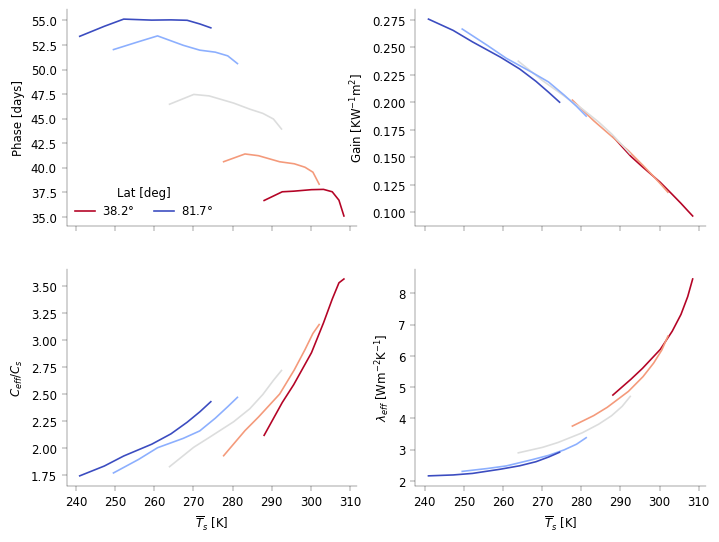

In [53]:
shift_lines = False         # So all cross through the origin, so can see gradient
color_lat = plt.colormaps["coolwarm_r"](np.linspace(0, 1, ds.lat.size))
fig, ax = plt.subplots(2, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax = ax.flatten()
for i in range(0, ds.lat.size):
    ds_use = ds.isel(lat=i)
    var = ds_use.t_surf.mean(dim='time')
    if use_sphum_col:
        var = ds_use.sphum_col.mean(dim='time')*1000
    if shift_lines:
        var = var-var.mean(dim='odp')
    var2 = [ds_use.coef_phase / omega / utils.day_seconds, ds_use.coef_amp/ds_use.coef_sw_amp,
            ds_use.heat_cap_multiplier, ds_use.lambda_eff]
    for j in range(len(var2)):
        ax[j].plot(var, var2[j] - var2[j].mean(dim='odp') if shift_lines else var2[j],
                   label=f"{ds_use.lat:.1f}$\degree$" if i%4==0 else None, color=color_lat[i])
ax[0].set_ylabel('Phase [days]')
ax[1].set_ylabel('Gain [KW$^{-1}$m$^2$]')
ax[2].set_ylabel('$C_{eff}/C_s$')
ax[3].set_ylabel('$\\lambda_{eff}$ [Wm$^{-2}$K$^{-1}$]')
if use_sphum_col:
    ax[2].set_xlabel('$\overline{q}_{col}$ [g/kg]')
    ax[3].set_xlabel('$\overline{q}_{col}$ [g/kg]')
else:
    ax[2].set_xlabel('$\overline{T}_s$ [K]')
    ax[3].set_xlabel('$\overline{T}_s$ [K]')
update_linewidth(fig)
ax[0].legend(ncol=2, title='Lat [deg]')
update_fontsize(fig, 7.2)
plt.show()

## Single Latitude
Now I look in more detail at a single latitude.

In [56]:
test = True     # only a few experiments
lat_sl = 40
vars_keep_sl = ['temp', 'ps', 'sphum', 'olr', 'swdn_toa', 'swdn_sfc', 'lwdn_sfc', 'lwup_sfc', 'flux_t',
                'flux_lhe', 't_surf']
ds_base_sl = []
if test:
    n_exp_sl = 3
    odp_slice = np.arange(3)
else:
    n_exp_sl = n_exp
    odp_slice = np.arange(n_exp)
for i, val in tqdm(enumerate(np.asarray(odp_vals, dtype=object)[odp_slice]), total=n_exp_sl):
    path_use = os.path.join(exp_dir, f"k={str(val).replace('.','_')}")
    ds_use = isca_tools.load_dataset(path_use, first_month_file=2 if 'column' in exp_dir else 25).sel(lat=lat_sl, method='nearest')[vars_keep_sl]
    ds_base_sl.append(ds_use.load())
ds_base_sl = xr.concat(ds_base_sl, dim=odp_vals_xr[odp_slice]).squeeze()

  0%|          | 0/3 [00:00<?, ?it/s]

In [57]:
if not isinstance(sigma_levels_full, xr.DataArray):
    sigma_levels_full = (ds_base_sl.pfull*0+sigma_levels_full).squeeze()

def get_p_eff(p_surf, temp=280, lapse_rate=6.5 / 1000):
    # Characteristic pressure for the q^* distribution, accounts for more q^* near the surface
    p_alpha_calc = 1000 * 100  # clausius clapeyron parameter is insensitive to pressure
    beta = clausius_clapeyron_factor(temp, p_alpha_calc) * lapse_rate * R * temp / g
    return (beta + 1) / (beta + 2) * p_surf

def get_temp_from_sphum_sat(sphum_sat_target, p, guess_temp: float = 280):
    fit_func = lambda x: sphum_sat(x, p) - sphum_sat_target
    return scipy.optimize.fsolve(fit_func, np.full_like(sphum_sat_target, guess_temp))

get_temp_from_sphum_sat_xr = wrap_with_apply_ufunc(get_temp_from_sphum_sat, input_core_dims=[[], []],
                                                   output_core_dims=[[]])

spline_deriv_periodic_xr = utils.wrap_with_apply_ufunc(spline_deriv_periodic,
                                                       input_core_dims=[['time'], ['time']],
                                                       output_core_dims=[['time']])

# Get optical depth at surface
odp_info = {'ir_tau_eq': 6, 'ir_tau_pole': 1.5, 'linear_tau': 0.1, 'wv_exponent': 4}  # default vals
for key in odp_info:  # If provided, update
    if key in namelist['two_stream_gray_rad_nml']:
        odp_info[key] = namelist['two_stream_gray_rad_nml'][key]
ds_base_sl['odp_surf'] = utils.opd_lw_gray(ds_base_sl.lat, kappa=ds_base_sl.odp, tau_eq=odp_info['ir_tau_eq'],
                             tau_pole=odp_info['ir_tau_pole'], frac_linear=odp_info['linear_tau'],
                             k_exponent=odp_info['wv_exponent'])  # optical depth as function of latitude

In [101]:
# Get radiative temperatures
ds_base_sl['temp_rad_surf'] = utils.get_temp_rad_surf(ds_base_sl.lwdn_sfc, ds_base_sl.odp_surf)
ds_base_sl['temp_rad_atm'] = utils.get_temp_rad_atm(ds_base_sl.olr, ds_base_sl.t_surf, ds_base_sl.odp_surf)

# Get column quantities - very important to use simpson integral method
ds_base_sl['temp_col'] = mass_weighted_vertical_integral(ds_base_sl.temp, ds_base_sl.ps * sigma_levels_full, 'pfull', simpson_method=True)
ds_base_sl['sphum_col'] = mass_weighted_vertical_integral(ds_base_sl.sphum, ds_base_sl.ps * sigma_levels_full, 'pfull', simpson_method=True)
ds_base_sl['rh_col'] = ds_base_sl['sphum_col'] / mass_weighted_vertical_integral(sphum_sat(ds_base_sl.temp, ds_base_sl.ps * sigma_levels_full),
                                                                                 ds_base_sl.ps * sigma_levels_full, 'pfull', simpson_method=True)

In [102]:
# Get zonal annual mean dataset
ds_sl = utils.get_annual_zonal_mean(ds_base_sl.sel(pfull=np.inf, method='nearest'))
ds_sl['p_eff'] = get_p_eff(ds_sl.ps.mean(dim='time'))
ds_sl['temp_col_sphum'] = get_temp_from_sphum_sat_xr(ds_sl.sphum_col / ds_sl.rh_col, ds_sl.p_eff)
ds_sl = ds_sl.rename_vars({'temp': 'temp_atm', 't_surf': 'temp_surf', 'ps': 'p_surf', 'sphum': 'q_atm'})
ds_sl['p_atm'] = ds_sl.p_surf * sigma_levels_full.sel(pfull=np.inf, method='nearest')
ds_sl['rh_atm'] = ds_sl.q_atm / sphum_sat(ds_sl.temp_atm, ds_sl.p_atm)

no lon dimension


In [111]:
# Get the contribution due to advection i.e., the convergence term on RHS of energy budget
p_calc_use = ds_sl.p_surf*(sigma_levels_full[-1]-sigma_levels_full[0])          # bounds of the integration

# Two methods for mse tend, prefer second as more directly related to the decomposition
# ds_sl['mse_tend'] = spline_deriv_periodic_xr(ds_sl.time*utils.day_seconds, (c_p*ds_sl.temp_col + L_v*ds_sl.sphum_col) * p_calc_use/g)
ds_sl['mse_tend'] = spline_deriv_periodic_xr(ds_sl.time*utils.day_seconds,
                                             (c_p*ds_sl.temp_col + L_v*ds_sl.rh_col*sphum_sat(ds_sl.temp_col_sphum, ds_sl.p_eff)) * p_calc_use/g)

ds_sl['flux_rhs'] = frierson_atmospheric_heating(ds_sl, albedo) + ds_sl.flux_t + ds_sl.flux_lhe
ds_sl['adv_total'] = ds_sl['mse_tend'] - ds_sl['flux_rhs']

### Check Atmospheric Energy Budget
This is closed by definition with advection, but for single column it serves as a sanity check.

Max error = 1.09 W/m2


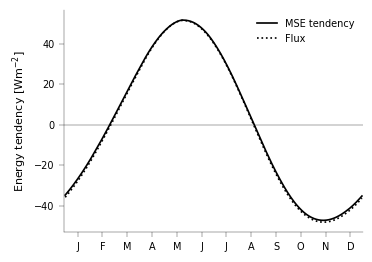

In [127]:
ind_use = 0
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'] * 0.7)
ax.plot(ds_sl.time, ds_sl['mse_tend'].isel(odp=ind_use), color='k', label='MSE tendency')
ax.plot(ds_sl.time, ds_sl['flux_rhs'].isel(odp=ind_use), color='k', label='Flux', linestyle=':')
if 'column' not in exp_dir:
    ax.plot(ds_sl.time, ds_sl['adv_total'].isel(odp=ind_use), color='C0', label='Advection')
else:
    print(f"Max error = {np.abs(ds_sl['adv_total'].isel(odp=ind_use)).max():.2f} W/m2")
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.legend()
plt.show()